EXPLORATORY DATA ANALYSIS AND PREPROCESSING: Exploratory Data Analysis (EDA) is the investigative process of visualizing and summarizing a dataset to reveal hidden patterns and relationships, serving as the "compass" that guides your modeling strategy. Data Preprocessing is the subsequent execution phase, where you apply mathematical transformations such as scaling, outlier removal, and class balancing to "sanitize" the data for algorithmic consumption. While EDA tells you what is happening in your data, Preprocessing ensures the data is technically fit to be used by a model, moving it from a raw, biased state into a structured, balanced format ready for training.

IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


LOAD DATA

In [3]:
df = pd.read_csv("C:/Users/USER/fraud_project/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

CATEGORIZING TARGET VARIABLE

In [5]:
df['Class'].unique()

array([0, 1])

REVEALING 'CLASS' IMBALANCE, GUIDING EVALUATION STRATEGY AND DECIDING ON DATA SAMPLING USING VALUE_COUNTS METHOD


In [6]:
counts= df['Class'].value_counts()
print(counts)

Class
0    284315
1       492
Name: count, dtype: int64


CHECKING FOR DUPLICATE VALUES
1081 DUPLICATES FOUND

In [7]:
df.duplicated().sum()

np.int64(1081)

In [8]:

duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows_sorted = duplicate_rows.sort_values(by=['Time', 'V1'])
duplicate_rows_sorted.head(12)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


DROPPING DUPLICATE ROWS

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


CHECKING FOR MISSING VALUES
NO MISSING VALUES FOUND

In [12]:
missing_values = df.isnull().sum()/len(df)*100
missing_values

Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64

COUNTPLOT: A Countplot is a bar chart that provides a stark visual representation of the class imbalance within a target variable. By showing the frequency of fraudulent versus legitimate transactions side-by-side, it highlights the extreme rarity of fraud cases, which warns the data scientist that standard accuracy metrics will be misleading. It essentially serves as the "reality check" that dictates whether you need to resample your data or adjust your evaluation metrics to ensure the model actually learns to identify the minority class.

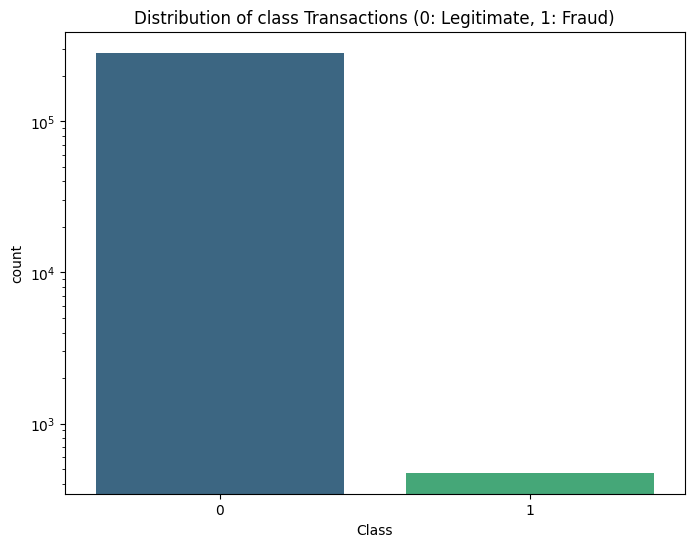

In [13]:
# Countplot for 'Class' distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)
plt.title('Distribution of class Transactions (0: Legitimate, 1: Fraud)')
plt.yscale('log') # Use log scale because 1s are so few they might not show up otherwise
plt.show()

THE AMOUNT DISTRIBUTION PLOT:The Amount Distribution plot allows to visually compare the financial scale of legitimate versus fraudulent activity, revealing whether fraudsters favor specific price points or behave differently than the average user. By using side-by-side histograms with density curves,you can identify if fraud is concentrated in small, "stealthy" amounts or large, high-risk charges. This insight is vital for feature engineering, as it helps decide if you should normalize the currency values or create specific "risk buckets" (e.g., "high-value" vs. "low-value") to help your machine learning model distinguish between the two classes.

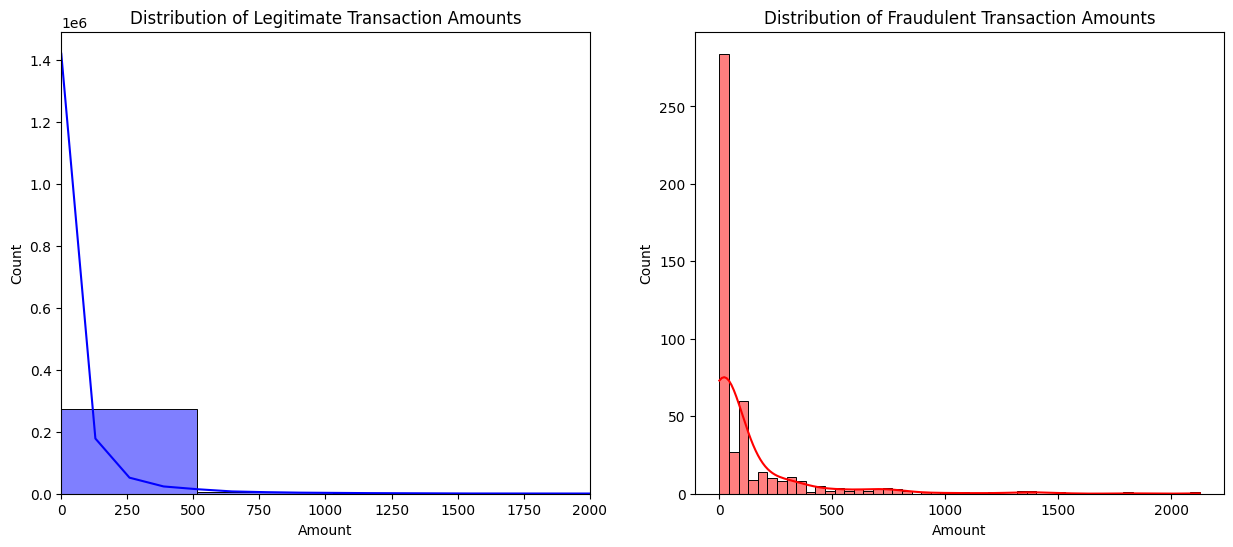

In [14]:
# Amount distribution for both classes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Legitimate
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=ax1, kde=True, color='blue')
ax1.set_title('Distribution of Legitimate Transaction Amounts')
ax1.set_xlim([0, 2000]) # Zooming in as most transactions are small

# Plot for Fraud
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=ax2, kde=True, color='red')
ax2.set_title('Distribution of Fraudulent Transaction Amounts')

plt.show()

In [15]:
# The distribution of fraudulent amount shows that lower transactions has the highest amount say $1.00.The histogram plot above
# is evidence and the value_counts() method also confirms it.Even the legitimate transactions is between 0 to $500.
# This means that most fraud attempts is of lower amounts.
print(df[df['Class'] == 1]['Amount'].value_counts().head())

Amount
1.00     105
99.99     27
0.00      25
0.76      17
0.77      10
Name: count, dtype: int64


CORRELATION HEATMAP PLOT:
The Correlation Heatmap serves as a visual compass for your data, condensing the complex relationships between all features into a single, color-coded grid. Its primary purpose is to identify which variables have a strong positive or negative "signal" with the Class variable, signaling that they are high-value predictors for detecting fraud. Simultaneously, it helps to spot multicollinearity, where two features provide redundant information, and validates that the  PCA-transformed features are independent (showing near-zero correlation with one another). Ultimately, it acts as a strategic filter, allowing to ignore "noise" and focus on deep-dive analysis and model training on the most impactful features.

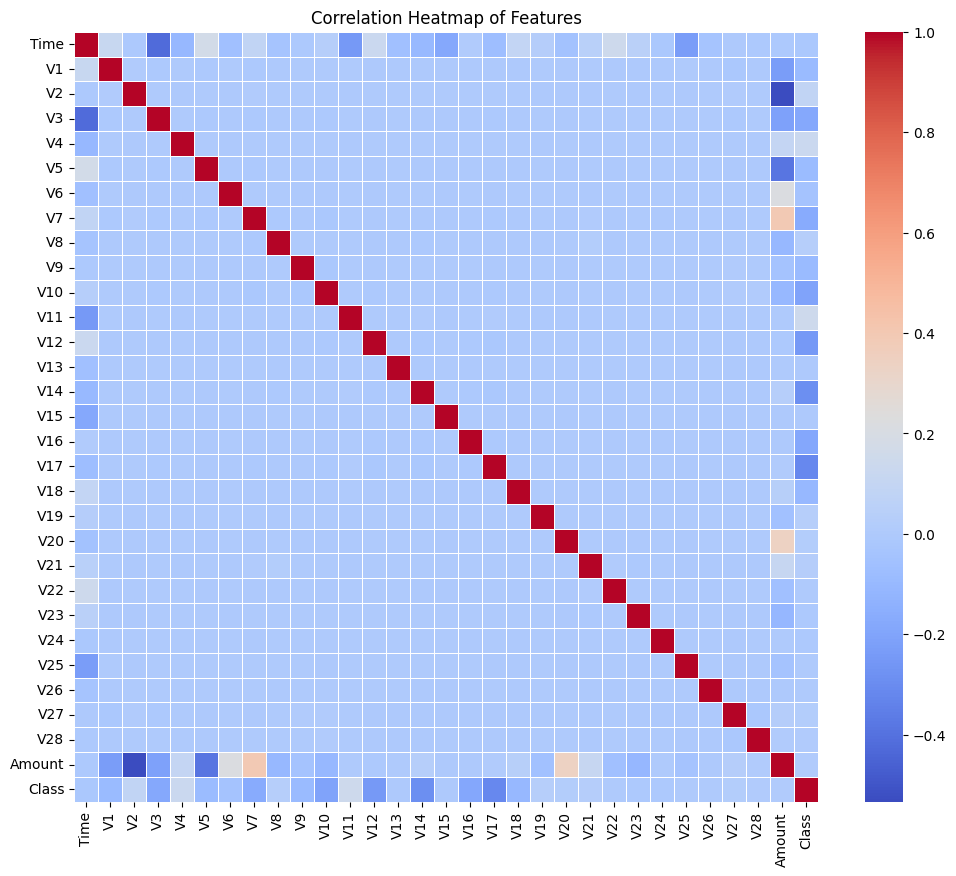

In [16]:
# Correlation matrix
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

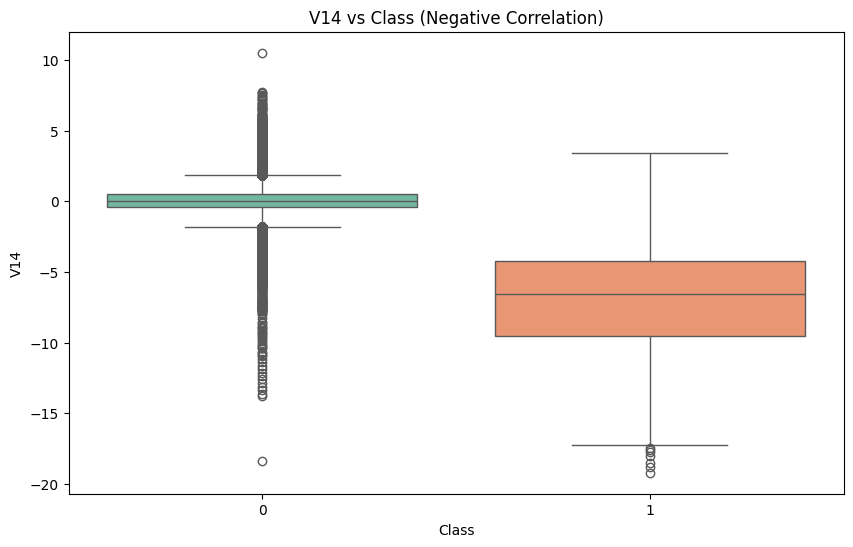

In [17]:
# Boxplots for Feature Comparison
# The heatmap above shows that certain features (like V14,V17 etc.) have a strong negative correlation with fraud, a boxplot 
# is necessary to see the difference in values.

# Comparing V14 distribution for Legitimate (0) vs Fraud (1)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='V14', data=df, hue='Class', palette='Set2', legend=False)
plt.title('V14 vs Class (Negative Correlation)')
plt.show()

IDENTIFYING AND REMOVING OUTLIERS

In [18]:
# From the box plot, you can see outliers. To identify and remove those extreme outliers from your V14 feature, 
# the Interquartile Range (IQR) method will be used. 
# This is a standard practice in data preprocessing to ensure your model doesn't "overfit" to extreme, rare values.
# Calculating the Bounds in the boxplot, the "whiskers" are usually drawn at 1.5*IQR. 
# Anything beyond that is mathematically considered an outlier.Q1(25th Percentile): The bottom of the orange box is Q3 (75th Percentile): 
# The top of your orange box.IQR: The height of the box (Q3 - Q1).

# 1. Isolate the V14 values for Fraud cases
v14_fraud = df['V14'].loc[df['Class'] == 1].values

# 2. Calculate Q1 and Q3
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
v14_iqr = q75 - q25

# 3. Calculate the Lower and Upper Outlier Cutoff
v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off

print(f"V14 Lower Bound: {v14_lower}")
print(f"V14 Upper Bound: {v14_upper}")

# 4. Identify outliers (the dots at the very bottom of the plot)
outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print(f"Total Outliers identified in V14: {len(outliers)}")

V14 Lower Bound: -17.38415366616548
V14 Upper Bound: 3.62654724179084
Total Outliers identified in V14: 7


In [19]:
# Removing outliers only for the fraud class to avoid accidentally deleting legitimate transactions that might just be "unusual" but valid. 
# This is extra safe.

df.drop(df[(df['Class'] == 1) & ((df['V14'] > v14_upper) | (df['V14'] < v14_lower))].index)
print(f"New Dataset Shape: {df.shape}")

New Dataset Shape: (283726, 31)


In [20]:
# 1. Isolate the V12 values for Fraud cases
v12_fraud = df['V12'].loc[df['Class'] == 1].values

# 2. Calculate Q1 (25th) and Q3 (75th) percentiles
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25

# 3. Calculate the Bounds (using the 1.5 multiplier)
v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off

print(f"V12 Lower Bound: {v12_lower}")
print(f"V12 Upper Bound: {v12_upper}")

# 4. Identify the outliers
outliers_v12 = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print(f"Total Outliers identified in V12: {len(outliers_v12)}")

# 5. Drop them from the main dataframe
df = df.drop(df[(df['Class'] == 1) & ((df['V12'] > v12_upper) | (df['V12'] < v12_lower))].index)
print(f"New Dataset Shape after V12 cleaning: {df.shape}")

V12 Lower Bound: -17.266702219761186
V12 Upper Bound: 5.840108332229608
Total Outliers identified in V12: 6
New Dataset Shape after V12 cleaning: (283720, 31)


In [21]:
# 1. Isolate the V10 values for Fraud cases
v10_fraud = df['V10'].loc[df['Class'] == 1].values

# 2. Calculate Q1 and Q3
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

# 3. Calculate the Bounds
v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off

print(f"V10 Lower Bound: {v10_lower}")
print(f"V10 Upper Bound: {v10_upper}")

# 4. Identify the outliers
outliers_v10 = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print(f"Total Outliers identified in V10: {len(outliers_v10)}")

# 5. Final Drop
df = df.drop(df[(df['Class'] == 1) & ((df['V10'] > v10_upper) | (df['V10'] < v10_lower))].index)
print(f"Final Dataset Shape: {df.shape}")

V10 Lower Bound: -14.193277613006945
V10 Upper Bound: 4.718202294642071
Total Outliers identified in V10: 25
Final Dataset Shape: (283695, 31)


SCALING USING ROBUSTSCALER: Since the previous plots showed the "Amount" column has a very long tail (outliers), RobustScaler is often superior because it uses the median and the interquartile range, making it less sensitive to extreme spending values.

In [29]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

# Apply to Amount and Time (Time is often scaled as well)
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

UNDER-SAMPLING

In [30]:
# Under-sampling (Balancing the Classes).The task here is to create a sub-sample. 
# A new dataframe where the number of Fraud and Legitimate cases are equal (50/50).
# This is called Random Under-sampling.Why do this?It forces the model to treat Fraud and Legitimate cases as equally important. 
# It will make the Correlation Heatmap much more colorful and easier to interpret.

# 1. Shuffle the data before creating the sub-sample
df = df.sample(frac=1)

# 2. Separate all fraud cases
fraud_df = df.loc[df['Class'] == 1]

# 3. Randomly select an equal amount of legitimate cases
# We use len(fraud_df) to make sure we have a 50/50 split
legit_df = df.loc[df['Class'] == 0][:len(fraud_df)]

# 4. Concatenate them into a new "Normal Distributed" dataframe
balanced_df = pd.concat([fraud_df, legit_df])

# 5. Shuffle the new balanced dataframe
new_df = balanced_df.sample(frac=1, random_state=42)

print(f"New Balanced Dataset Shape: {new_df.shape}")
print(new_df['Class'].value_counts())

New Balanced Dataset Shape: (884, 31)
Class
1    442
0    442
Name: count, dtype: int64


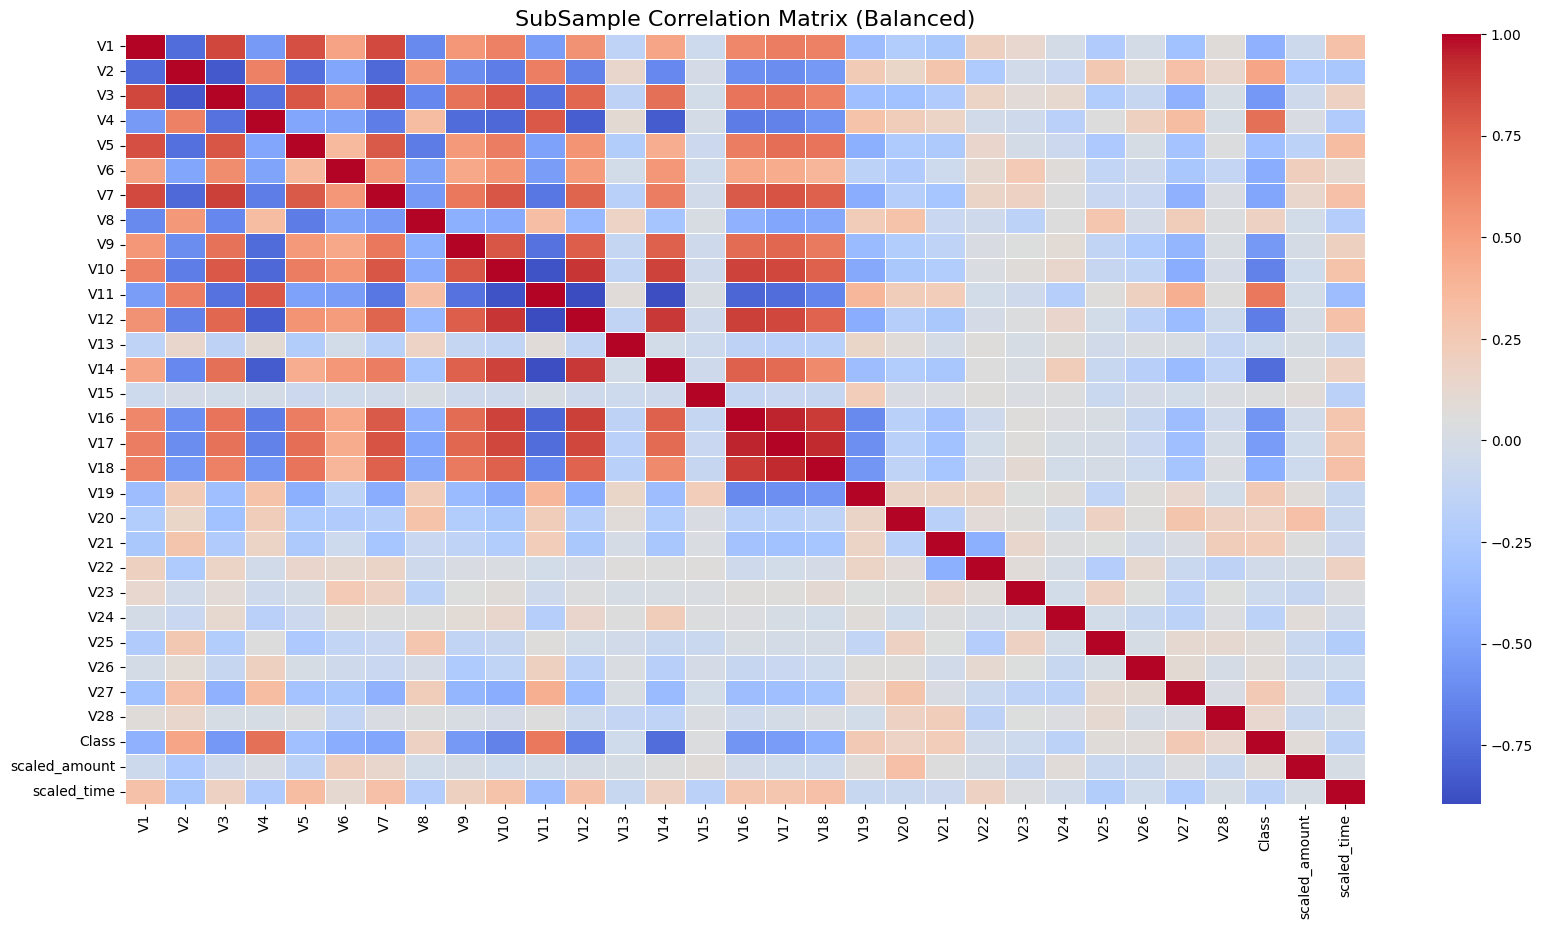

In [31]:
# The subsample correlation matrix(balanced)

plt.figure(figsize=(20, 10))

# Using the balanced dataframe 'new_df'
sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('SubSample Correlation Matrix (Balanced)', fontsize=16)
plt.show()

By performing under-sampling, you successfully amplified the hidden signals within the dataset, creating a SubSample Correlation Matrix where the relationships between features and fraud are far more pronounced. Unlike the original heatmap, which was visually diluted by the massive class imbalance. This balanced view clearly identifies V10, V12, V14, and V17 as powerful negative predictors and V4 and V11 as strong positive predictors of fraudulent activity. This visualization confirms that the preprocessing specifically the scaling and balancing has transformed the data into a state where a machine learning model can easily distinguish the underlying patterns of theft from normal spending behavior.

CREATING BOXPLOTS:Creating boxplots again on the features identified by your balanced heatmap allows you to move from general correlation to specific data distributions, revealing how clearly the fraudulent and legitimate classes are separated. These plots highlight the median differences and the spread of data, making it obvious which features provide the most distinct "classification boundary" for an algorithm to follow. Furthermore, they serve as a critical diagnostic tool for identifying extreme outliers in the fraud class, helping you decide whether to trim specific data points that might otherwise skew the model's understanding of what constitutes a typical fraudulent transaction.

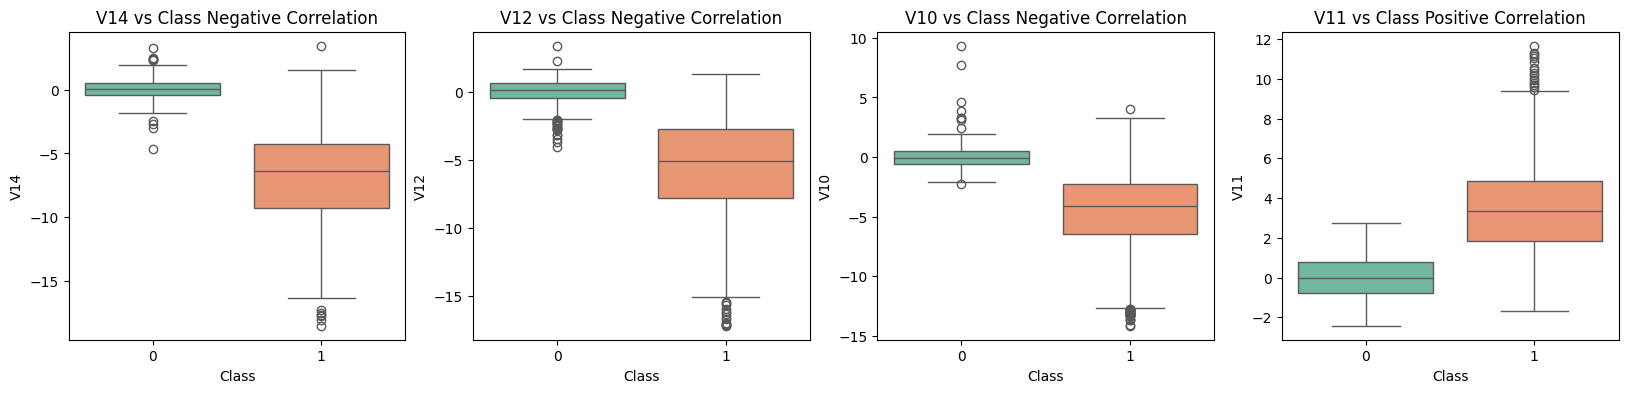

In [34]:
# Create subplots to compare the most correlated features
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Negative Correlations (As these decrease, Fraud increases)
sns.boxplot(x="Class", y="V14", data=new_df, hue="Class", palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", data=new_df, hue="Class", palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V10", data=new_df, hue="Class", palette='Set2', ax=axes[2], legend=False)
axes[2].set_title('V10 vs Class Negative Correlation')

# Positive Correlation (As this increases, Fraud increases)
sns.boxplot(x="Class", y="V11", data=new_df, hue="Class", palette='Set2', ax=axes[3], legend=False)
axes[3].set_title('V11 vs Class Positive Correlation')

plt.show()

The Class Comparison Boxplots confirm that the selected features possess high discriminatory power, as evidenced by the clear physical separation between the legitimate and fraudulent distributions. For features like V14 and V12, the fraudulent class exhibits significantly lower medians, while V11 shows a starkly higher median, providing the machine learning algorithm with distinct "decision boundaries" to exploit. The minimal overlap between the interquartile ranges suggests that these variables are robust indicators, though the presence of remaining outliers in the fraud class highlights the extreme variability inherent in criminal transaction patterns.

SPLITTING DATA INTO TRAINING AND TESTING

In [35]:
# X is everything except the 'Class' column
X = new_df.drop('Class', axis=1)

# y is just the 'Class' column
y = new_df['Class']

In [36]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time
143335,-6.713407,3.921104,-9.746678,5.148263,-5.151563,-2.099389,-5.937767,3.578780,-4.684952,-8.537758,...,0.954272,-0.451086,0.127214,-0.339450,0.394096,1.075295,1.649906,-0.394905,3.211013,0.007027
52584,-1.519244,2.308492,-1.503599,2.064101,-1.000845,-1.016897,-2.059731,-0.275166,-1.562206,-2.755797,...,1.307871,0.102826,-0.017746,0.149696,-0.096602,-0.369115,-0.019244,-0.208319,-0.292011,-0.460019
196709,2.004997,0.150927,-1.633999,1.197820,0.587294,-0.606496,0.477145,-0.223516,0.018368,0.423235,...,0.043486,0.308213,-0.019437,-0.401363,0.406767,-0.532233,-0.015937,-0.073692,-0.195370,0.551915
203983,1.541791,-0.798280,-0.597381,1.548773,-0.379270,0.290336,-0.103020,0.104939,0.909503,0.062694,...,-0.373728,-1.227512,0.225434,-0.469194,-0.387619,-1.119477,0.018493,-0.011336,2.418828,0.591963
244272,-1.398084,0.573398,0.838034,-2.357363,-0.428302,-0.735827,1.045912,-1.277534,-1.300999,-0.018443,...,0.638483,-0.584664,-0.088304,0.024835,0.696494,-0.402570,-0.221081,-0.043308,1.368977,0.794298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108708,-3.170818,0.185735,-3.399852,3.761155,-2.148047,-1.598944,-2.519565,1.316215,-2.400106,-4.993417,...,1.092051,-0.041080,0.904395,0.180016,0.049970,-0.257100,0.859282,0.225924,5.623305,-0.160453
142405,-4.868108,1.264420,-5.167885,3.193648,-3.045621,-2.096166,-6.445610,2.422536,-3.214055,-8.745973,...,1.269205,0.057657,0.629307,-0.168432,0.443744,0.276539,1.441274,-0.127944,-0.134742,0.000082
114419,-1.146518,-0.133377,1.838427,-1.635474,-0.762018,-0.453131,-0.742861,0.573888,-1.216831,-0.386275,...,0.585014,1.321996,-0.191443,0.131736,0.036772,-0.175182,-0.000056,-0.020258,0.041577,-0.131768
123270,1.082566,1.094862,-1.367020,2.012554,0.708142,-0.807712,0.151952,0.158353,0.009872,-1.925278,...,-0.325284,-0.734344,-0.106725,-0.224999,0.569167,-0.335033,0.089140,0.112337,-0.292011,-0.091896


In [37]:
y

143335    1
52584     1
196709    0
203983    0
244272    0
         ..
108708    1
142405    1
114419    0
123270    1
237107    1
Name: Class, Length: 884, dtype: int64

In [38]:
from sklearn.model_selection import train_test_split

# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((707, 30), (177, 30), (707,), (177,))